# Factor Spanning Tests

A central task in empirical asset pricing is to determine whether a proposed factor adds something to an existing model. Much of this literature is deliberately practical: researchers construct diversified portfolio returns and ask whether established factors explain their average returns and time-series variation.

This research program grew out of the empirical limitations of the Capital Asset Pricing Model (CAPM). Market beta alone struggled to explain prominent size and value patterns, followed later by profitability and investment evidence. These findings motivated multifactor models, most notably the Fama–French models. We use the familiar five-factor setting to demonstrate the general logic of time-series regressions and factor-spanning tests.

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from factor_asset_pricing.asset_pricing_tests import factor_regressions
pd.options.display.float_format="{:,.3f}".format; plt.style.use("seaborn-v0_8-whitegrid")
ROOT=Path.cwd().resolve(); ROOT=ROOT.parent if ROOT.name=="notebooks" else ROOT
DEFAULT_DATA=ROOT.parent/"01_complete/fama-french-five-factor-replication/data/interim/Python"
DATA=Path(os.environ.get("FAP_FF5_DATA_DIR", DEFAULT_DATA))
factors=pd.read_parquet(DATA/"ff5_factors_internal.parquet").set_index("mdate").dropna()
portfolios=pd.read_parquet(DATA/"ff5_test_portfolios.parquet"); portfolios["mdate"]=pd.to_datetime(portfolios["mdate"])

## 1. Asset-pricing models, spanning, and inference

### 1.1 The Capital Asset Pricing Model (CAPM)

Markowitz (1952) showed how diversification links expected return to portfolio risk. Sharpe (1964) and Lintner (1965) added equilibrium and made the market portfolio theoretically central. In the CAPM, an asset's expected excess return depends only on its exposure to the market excess return:

$$E[R_i-R_f]=\beta_{i,M}E[R_M-R_f],\qquad \beta_{i,M}=\frac{\operatorname{Cov}(R_i-R_f,R_M-R_f)}{\operatorname{Var}(R_M-R_f)}.$$

The corresponding time-series regression is

$$R^e_{i,t}=\alpha_i+\beta_{i,M}MKT_t+\varepsilon_{i,t},\qquad MKT_t=R_{M,t}-R_{f,t}.$$

The intercept is Jensen's alpha (Jensen, 1968): average excess return left unexplained by market exposure. The CAPM restriction is tested as

$$H_0:\alpha_i=0,\qquad H_1:\alpha_i\neq0.$$

Rejecting the null means that CAPM does not explain the asset's average excess return over the sample. It does not, by itself, distinguish omitted risk from mispricing, market-proxy error, or sampling variation.

The textbook CAPM assumes a common investment horizon, mean–variance portfolio choice, shared beliefs, frictionless markets, and borrowing/lending at a common risk-free rate. The theoretical market portfolio includes all risky wealth; an equity-market proxy makes the empirical test a joint test of the model and that proxy.


### 1.2 From CAPM failure to multifactor models

The size and value evidence documented by Fama and French (1992, 1993), and the profitability and investment evidence incorporated by Fama and French (2015), suggested that market exposure alone was insufficient. A general linear factor model allows several sources of systematic return variation:

$$R^e_{i,t}=\alpha_i+\boldsymbol{\beta}_i'\mathbf F_t+\varepsilon_{i,t}.$$

For the five-factor model this becomes

$$R^e_{i,t}=\alpha_i+\beta_{i,M}MKT_t+\beta_{i,S}SMB_t+\beta_{i,H}HML_t+\beta_{i,R}RMW_t+\beta_{i,C}CMA_t+\varepsilon_{i,t}.$$

The loadings measure exposure to market, size, value, profitability, and investment factor returns. For each factor $k$, researchers often test

$$H_0:\beta_{i,k}=0,\qquad H_1:\beta_{i,k}\neq0.$$

A significant loading establishes empirical exposure to that factor. Calling it exposure to a *priced risk* additionally requires evidence that the factor earns a risk premium and explains differences in expected returns across assets; a time-series loading test alone cannot establish that claim.

Here $\boldsymbol\beta_i$ is constant across the estimation sample and denotes a population linear projection with $E[\varepsilon_{i,t}]=0$ and $E[\varepsilon_{i,t}\mathbf F_t]=\mathbf0$. Consequently $\alpha_i=E[R^e_{i,t}]-\boldsymbol\beta_i'E[\mathbf F_t]$. These unconditional regressions do not estimate state-dependent expected returns or exposures.


### 1.3 Factor spanning and economic interpretation

A factor-spanning regression treats a candidate factor's **excess return**, $R^e_{G,t}$, as the dependent variable and an established factor model as the benchmark:

$$R^e_{G,t}=\alpha+\boldsymbol{\beta}'\mathbf F_t+\varepsilon_t.$$

For a long-only candidate portfolio, $R^e_{G,t}=R_{G,t}-R_{f,t}$. For a self-financing long–short factor, the risk-free return cancels between the two legs, $(R_{L,t}-R_{f,t})-(R_{S,t}-R_{f,t})=R_{L,t}-R_{S,t}$, so the reported factor return is already an excess return. The benchmark factors on the right-hand side are likewise expressed as excess or self-financing returns.

The central hypothesis is

$$H_0:\alpha=0,\qquad H_1:\alpha\neq0.$$

Alpha measures unexplained average return, the loadings measure benchmark-factor exposure, and adjusted $R^2$ measures the share of time-series variation explained while accounting for model size. A model can explain much of a factor's monthly variation and still fail to explain its average return.

For the population projection, $E[\varepsilon_t]=0$ and $E[\varepsilon_t\mathbf F_t]=\mathbf0$. With nonsingular covariance matrices, unrestricted long/short trading, and a risk-free asset, zero alpha means the candidate does not increase the benchmark's maximum attainable squared Sharpe ratio (Gibbons, Ross, and Shanken, 1989). This is the excess-return mean–variance spanning restriction used here. Exact return replication is stronger: it requires $\operatorname{Var}(\varepsilon_t)=0$ as well. A zero-alpha candidate can still have substantial unexplained monthly variation.

A statistically significant estimated alpha is evidence against the population zero-alpha restriction. A merely nonzero sample estimate is insufficient, and failure to reject does not prove spanning. Sample opportunity-set improvements are measured before transaction costs, constraints, and out-of-sample uncertainty.

### 1.4 OLS and Newey–West inference

Let $\mathbf x_t=(1,\mathbf F_t')'$ contain $d=K+1$ regressors, let $X$ have rows $\mathbf x_t'$, and let $\mathbf y$ contain the candidate excess returns. With full column rank,

$$\widehat{\boldsymbol\theta}=(X'X)^{-1}X'\mathbf y,\qquad \boldsymbol\theta=(\alpha,\boldsymbol\beta')'.$$

Newey and West (1987) retain these coefficients and estimate uncertainty from the residual scores $\mathbf z_t=\mathbf x_t\widehat\varepsilon_t$. Define

$$\widehat\Gamma_\ell=\frac1T\sum_{t=\ell+1}^T\mathbf z_t\mathbf z_{t-\ell}',\qquad
\widehat S_L=\widehat\Gamma_0+\sum_{\ell=1}^L\left(1-\frac{\ell}{L+1}\right)(\widehat\Gamma_\ell+\widehat\Gamma_\ell').$$

With $Q=X'X/T$, the package's Bartlett-kernel HAC covariance, including its degrees-of-freedom correction, is

$$\widehat{\operatorname{Var}}(\widehat{\boldsymbol\theta})=\frac{T}{T-d}\frac1T Q^{-1}\widehat S_L Q^{-1}.$$

For coefficient $\theta$, $t=(\widehat\theta-\theta_0)/SE_{NW}(\widehat\theta)$. Inference uses the asymptotic normal approximation, not an exact finite-sample Student distribution. HAC consistency requires suitable finite moments, weak dependence, and a nonsingular regressor moment matrix; it does not cure look-ahead bias or model misspecification.

We use $L=12$ monthly observation lags as a transparent convention. The one-year interpretation presumes a consecutive monthly estimation sample: dropping dates makes adjacent rows unequal to adjacent calendar months.


## 2. Example: The Fama–French five factors and anomalies

The Fama–French factors provide familiar examples of characteristic portfolio strategies. MKT represents broad equity-market exposure, while SMB, HML, RMW, and CMA compress return patterns associated with size, book-to-market, profitability, and investment. Here these factors are candidate returns in CAPM spanning tests; estimating the complete five-factor model is reserved for the next notebook.

### 2.1 The Fama-French Five Factors
Following Fama and French (2015), French (n.d.), and Notebook 1, the characteristic factors are constructed from value-weighted returns on independent Size × B/M, Size × OP, and Size × INV portfolios:

$$HML=\tfrac12(SH+BH)-\tfrac12(SL+BL),$$
$$RMW=\tfrac12(SR+BR)-\tfrac12(SW+BW),\qquad CMA=\tfrac12(SC+BC)-\tfrac12(SA+BA).$$

Each family also produces a small-minus-big spread, and the published size factor averages the three components:

$$SMB^{BM}=\tfrac13(SL+SM+SH)-\tfrac13(BL+BM+BH),$$
$$SMB^{OP}=\tfrac13(SW+SN+SR)-\tfrac13(BW+BN+BR),$$
$$SMB^{INV}=\tfrac13(SA+SN+SC)-\tfrac13(BA+BN+BC),$$
$$SMB=\tfrac13(SMB^{BM}+SMB^{OP}+SMB^{INV}).$$

Each characteristic factor takes a value-weighted long position in one set of portfolios and a value-weighted short position in another. The weights within each leg are normalized to one; after assigning negative signs to the short leg, the signed weights sum to zero. The factors are therefore dollar-neutral, self-financing portfolio returns and are essentially tradable strategies before allowing for transaction costs, turnover, and short-selling constraints. Because the short position finances the long position, the risk-free return cancels and is not subtracted again.

The cumulative plots below separate MKT from the four characteristic factors so that the smaller long–short return paths remain visible.

Within each family, the first letter identifies size. The second is L/M/H for book-to-market, W/N/R for profitability, or A/N/C for investment; N denotes neutral. Cell returns are value weighted, while the cell portfolios enter each factor leg with equal weights. A normalized long–short spread has unit long and unit short notional, rather than a defined return on zero net capital.


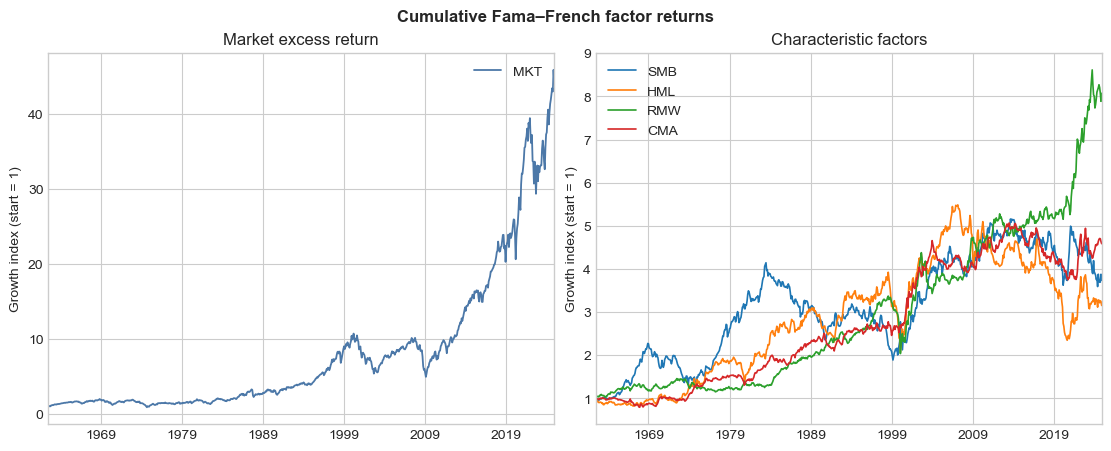

In [2]:
factor_panel=factors[["MKT","SMB","HML","RMW","CMA"]]; wealth=(1+factor_panel).cumprod()
fig,axes=plt.subplots(1,2,figsize=(11,4.4),constrained_layout=True)
wealth[["MKT"]].plot(ax=axes[0],color="#4C78A8",linewidth=1.3); wealth[["SMB","HML","RMW","CMA"]].plot(ax=axes[1],linewidth=1.2)
axes[0].set(title="Market excess return",ylabel="Growth index (start = 1)",xlabel=""); axes[1].set(title="Characteristic factors",ylabel="Growth index (start = 1)",xlabel=""); fig.suptitle("Cumulative Fama–French factor returns",weight="bold"); plt.show()

None of the characteristic factors dominates the market cumulatively over this sample—an ambitious benchmark that is generally difficult for a single long–short strategy to beat. Their paths nevertheless differ visibly from MKT and from one another. That distinct behavior motivates the spanning question: does a characteristic strategy deliver average excess return that cannot be explained by its market exposure? The panels are normalized growth indices for comparing return histories; the long–short panel is not the value of an unlevered one-dollar cash investment.

### 2.1. CAPM factor-spanning tests

For each characteristic factor $F_t\in\{SMB,HML,RMW,CMA\}$, we estimate

$$F_t=\alpha+\beta_M MKT_t+\varepsilon_t$$

by OLS and report Newey–West inference with 12 lags. The alpha test evaluates CAPM spanning; the beta test evaluates market exposure; adjusted $R^2$ summarizes time-series fit.

In [3]:
anomaly_factors=factor_panel[["SMB","HML","RMW","CMA"]]
capm=factor_regressions(anomaly_factors,factor_panel[["MKT"]],cov_type="HAC",hac_lags=12)
results=capm[["alpha","alpha_t","beta_MKT","beta_MKT_t","adjusted_r_squared"]].copy(); results["alpha"]*=100
results.columns=["Alpha (% per month)","NW alpha t","Market beta","NW beta t","Adjusted R²"]; display(results)

,Alpha (% per month),NW alpha t,Market beta,NW beta t,Adjusted R²
asset,,,,,
SMB,0.110,0.891,0.184,6.410,0.072
HML,0.295,2.082,-0.159,-3.147,0.056
RMW,0.345,3.667,-0.072,-1.973,0.022
CMA,0.307,3.822,-0.139,-4.953,0.100


The table provides the formal spanning evidence. HML, RMW, and CMA have positive monthly CAPM alphas with absolute Newey–West $t$-statistics above 1.96, so their alphas are statistically significant at the 5% two-sided level in this sample. SMB's alpha is smaller and not statistically significant. The market loadings are statistically significant, but the adjusted $R^2$ values remain low—roughly 2% to 10%—so MKT explains only a limited share of these factors' monthly variation. The precise conclusion is that CAPM fails to span HML, RMW, and CMA over this sample; it is not, by itself, proof of mispricing or of a structural risk premium.

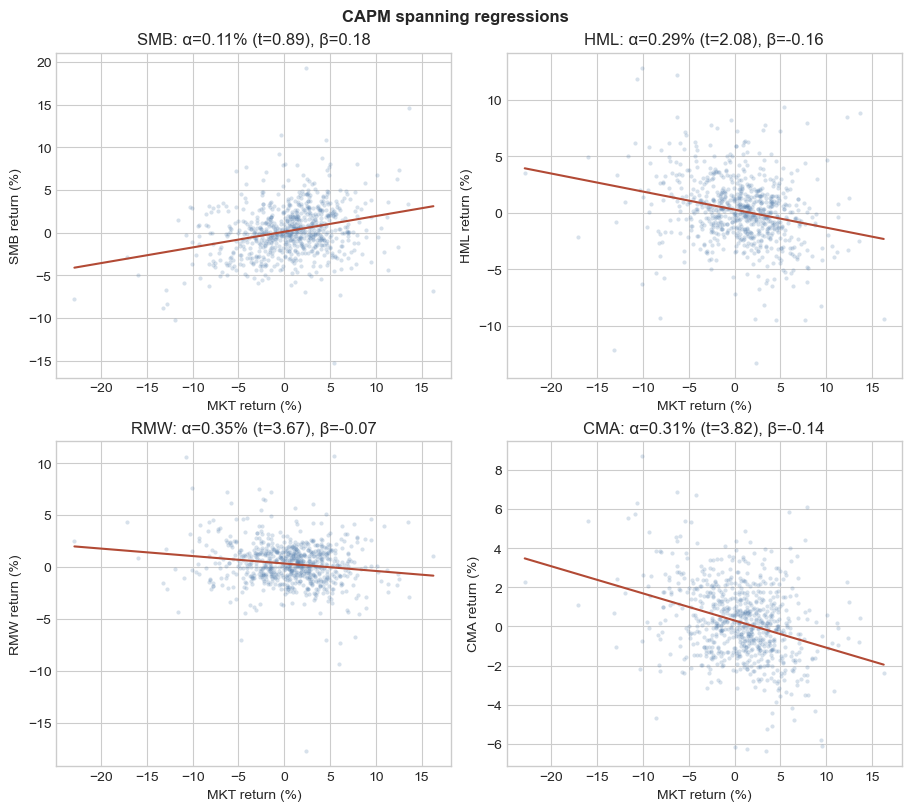

In [4]:
fig,axes=plt.subplots(2,2,figsize=(9,8),constrained_layout=True); x=factor_panel["MKT"]*100
for ax,name in zip(axes.flat,anomaly_factors):
    sample=pd.concat([x.rename("MKT"),(anomaly_factors[name]*100).rename(name)],axis=1).dropna(); grid=np.linspace(sample.MKT.min(),sample.MKT.max(),100); alpha=capm.loc[name,"alpha"]*100; beta=capm.loc[name,"beta_MKT"]
    ax.scatter(sample.MKT,sample[name],s=9,alpha=.22,color="#4C78A8",linewidths=0); ax.plot(grid,alpha+beta*grid,color="#B24A35",lw=1.5)
    ax.set(title=f"{name}: α={alpha:.2f}% (t={capm.loc[name,'alpha_t']:.2f}), β={beta:.2f}",xlabel="MKT return (%)",ylabel=f"{name} return (%)")
fig.suptitle("CAPM spanning regressions",weight="bold"); plt.show()

The fitted lines visualize the same regressions rather than provide a separate test. Their intercepts correspond to the table's estimated alphas, while their relatively shallow slopes and widely dispersed monthly observations are consistent with the low adjusted $R^2$ values. HML, RMW, and CMA therefore sit above the zero-alpha CAPM benchmark on average, whereas SMB's estimated intercept is too imprecise to distinguish from zero. The plots reinforce the statistical result, but significance is determined by the Newey–West $t$-statistics in the table—not by visual distance from the fitted line.

### 2.2 Overlapping characteristic patterns and the role of size

Candidate anomalies need not represent independent mechanisms. Characteristics can be correlated and their return patterns can be concentrated among the same firms. The Size × BM, Size × OP, and Size × INV portfolios reveal whether characteristic-related average returns appear across size groups or mainly in one segment.

Fama–French 2×3 sorts do not residualize characteristics with respect to size. Size and the second characteristic are sorted independently; the characteristic spread is then formed within small and big firms and averaged across the two size groups. This reduces direct size contamination without residualizing size away.

The heatmaps below use separate 5×5 test-portfolio families prepared by the companion project. They are not the 2×3 constituent portfolios used to construct the characteristic factors.


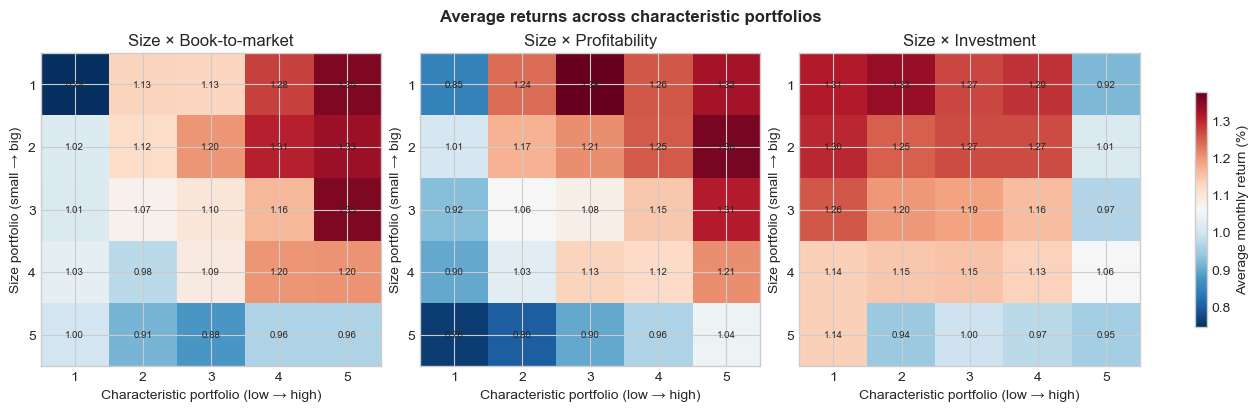

In [5]:
means={}
for family,label in [("size_bm","Book-to-market"),("size_op","Profitability"),("size_inv","Investment")]:
    data=portfolios.loc[portfolios.family.eq(family)]; means[label]=data.pivot_table(index="row_portfolio",columns="column_portfolio",values="ret",aggfunc="mean").astype(float)*100
fig,axes=plt.subplots(1,3,figsize=(12.5,4),constrained_layout=True); lower=min(t.min().min() for t in means.values()); upper=max(t.max().max() for t in means.values())
for ax,(label,table) in zip(axes,means.items()):
    image=ax.imshow(table,cmap="RdBu_r",aspect="auto",vmin=lower,vmax=upper)
    for (r,c),value in np.ndenumerate(table.to_numpy()): ax.text(c,r,f"{value:.2f}",ha="center",va="center",fontsize=7)
    ax.set(title=f"Size × {label}",xlabel="Characteristic portfolio (low → high)",ylabel="Size portfolio (small → big)",xticks=range(5),xticklabels=range(1,6),yticks=range(5),yticklabels=range(1,6))
fig.colorbar(image,ax=axes,shrink=.75,label="Average monthly return (%)"); fig.suptitle("Average returns across characteristic portfolios",weight="bold"); plt.show()

The heatmaps show that characteristic patterns are not uniform across size groups. This is why factor construction compares characteristic portfolios within both small and big firms before averaging the spreads. The resulting factors compress a richer cross-section, but the patterns alone do not establish that each characteristic represents a distinct priced risk.

## References

- Fama, E. F., and French, K. R. (1992). The cross-section of expected stock returns. *The Journal of Finance*, 47(2), 427–465. [DOI](https://doi.org/10.1111/j.1540-6261.1992.tb04398.x).

- Fama, E. F., and French, K. R. (1993). Common risk factors in the returns on stocks and bonds. *Journal of Financial Economics*, 33(1), 3–56. [DOI](https://doi.org/10.1016/0304-405X(93)90023-5).

- Fama, E. F., and French, K. R. (2015). A five-factor asset pricing model. *Journal of Financial Economics*, 116(1), 1–22. [DOI](https://doi.org/10.1016/j.jfineco.2014.10.010).

- French, K. R. (n.d.). Description of Fama/French five factors (2×3). *Data Library, Dartmouth College*. [Construction details](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_5_factors_2x3.html). Accessed 10 October 2026.

- Gibbons, M. R., Ross, S. A., and Shanken, J. (1989). A test of the efficiency of a given portfolio. *Econometrica*, 57(5), 1121–1152. [DOI](https://doi.org/10.2307/1913625).

- Jensen, M. C. (1968). The performance of mutual funds in the period 1945–1964. *The Journal of Finance*, 23(2), 389–416. [DOI](https://doi.org/10.1111/j.1540-6261.1968.tb00815.x).

- Lintner, J. (1965). The valuation of risk assets and the selection of risky investments in stock portfolios and capital budgets. *The Review of Economics and Statistics*, 47(1), 13–37. [DOI](https://doi.org/10.2307/1924119).

- Markowitz, H. (1952). Portfolio selection. *The Journal of Finance*, 7(1), 77–91. [DOI](https://doi.org/10.1111/j.1540-6261.1952.tb01525.x).

- Newey, W. K., and West, K. D. (1987). A simple, positive semi-definite, heteroskedasticity and autocorrelation consistent covariance matrix. *Econometrica*, 55(3), 703–708. [DOI](https://doi.org/10.2307/1913610).

- Sharpe, W. F. (1964). Capital asset prices: A theory of market equilibrium under conditions of risk. *The Journal of Finance*, 19(3), 425–442. [DOI](https://doi.org/10.1111/j.1540-6261.1964.tb02865.x).
